# MSK Problem B - CORRECTED Multi-Model Training
## Myositis Classification: DM vs PM vs IBM

**FIXED Issues from previous run:**
- ✅ Learning rate: 1e-5 (was 1e-4 - 10x too high!)
- ✅ Conservative augmentation (matching original)
- ✅ Simpler head architecture (matching original 67% config)

**Class Distribution:**
- Dermatomyositis (D): 555
- Polymyositis (P): 553
- IBM (I): 794

**Reference:** Burlina et al. 2017 achieved 74.8% for IBM vs DM/PM

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Set Your Paths

In [2]:
import os

# ⚠️ CHANGE THIS TO YOUR DRIVE PATH
BASE_DIR = "/content/drive/MyDrive/MSK project"

EXCEL_PATH = os.path.join(BASE_DIR, "PatientImages_MATCHED.xlsx")
IMG_DIR = os.path.join(BASE_DIR, "processed_images")
RESULTS_DIR = os.path.join(BASE_DIR, "results_v2")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints_v2")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checking paths...")
print(f"  Base dir exists: {os.path.exists(BASE_DIR)}")
print(f"  Excel exists: {os.path.exists(EXCEL_PATH)}")
print(f"  Images dir exists: {os.path.exists(IMG_DIR)}")

if os.path.exists(IMG_DIR):
    print(f"  Number of images: {len(os.listdir(IMG_DIR))}")

Checking paths...
  Base dir exists: True
  Excel exists: True
  Images dir exists: True
  Number of images: 3214


## Step 3: Import Libraries

In [3]:
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from tensorflow.keras.applications import (
    ResNet50, ResNet101, EfficientNetB0, EfficientNetB4, VGG16, DenseNet121, InceptionV3, Xception
)
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

print("✅ All libraries imported!")
print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported!
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 4: CORRECTED Configuration
⚠️ **Key fix: Learning rate = 1e-5** (matching your original 67% config)

In [4]:
FILENAME_COL = "filename"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40

# ⚠️ CRITICAL FIX: Use 1e-5, NOT 1e-4!
LEARNING_RATE = 1e-5

tf.random.set_seed(42)
np.random.seed(42)

# Model configs matching original successful settings
MODEL_CONFIGS = {
    "ResNet101_Original": {
        "base_model": ResNet101,
        "preprocess": resnet_preprocess,
        "unfreeze_layers": 80,
        "head": "simple",  # Single Dense(512) like original
    },
    "ResNet50_Original": {
        "base_model": ResNet50,
        "preprocess": resnet_preprocess,
        "unfreeze_layers": 50,
        "head": "simple",
    },
    "EfficientNetB0_Simple": {
        "base_model": EfficientNetB0,
        "preprocess": effnet_preprocess,
        "unfreeze_layers": 80,
        "head": "simple",
    },
    "EfficientNetB4": {
        "base_model": EfficientNetB4,
        "preprocess": effnet_preprocess,
        "unfreeze_layers": 100,
        "head": "simple",
    },
    "DenseNet121_Simple": {
        "base_model": DenseNet121,
        "preprocess": densenet_preprocess,
        "unfreeze_layers": 80,
        "head": "simple",
    },
    "InceptionV3": {
        "base_model": InceptionV3,
        "preprocess": inception_preprocess,
        "unfreeze_layers": 100,
        "head": "simple",
    },
    "Xception": {
        "base_model": Xception,
        "preprocess": xception_preprocess,
        "unfreeze_layers": 80,
        "head": "simple",
    },
}

PROGRESS_FILE = os.path.join(CHECKPOINT_DIR, "progress_v2.json")

print("✅ Configuration set (LR = 1e-5)")

✅ Configuration set (LR = 1e-5)


## Step 5: Progress Tracking (Crash Recovery)

In [5]:
def save_progress(completed, results):
    with open(PROGRESS_FILE, 'w') as f:
        json.dump({"completed": completed, "results": results, "time": datetime.now().isoformat()}, f, indent=2)
    print(f"💾 Progress saved! Completed: {completed}")

def load_progress():
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE, 'r') as f:
            p = json.load(f)
        print(f"📂 Found progress: {p['completed']}")
        return p['completed'], p['results']
    return [], []

def clear_progress():
    if os.path.exists(PROGRESS_FILE):
        os.remove(PROGRESS_FILE)
        print("🗑️ Progress cleared!")

print("✅ Progress functions ready!")

✅ Progress functions ready!


## Step 6: Load Data

In [6]:
def find_diagnosis_column(df):
    target = {"D", "P", "I", "N"}
    best_col, best_overlap = None, 0
    for c in df.columns:
        vals = set(df[c].astype(str).str.strip().dropna().unique())
        overlap = len(vals & target)
        if overlap > best_overlap:
            best_overlap, best_col = overlap, c
    return best_col

df = pd.read_excel(EXCEL_PATH)
diag_col = find_diagnosis_column(df)
print(f"✅ Diagnosis column: {diag_col}")

df[diag_col] = df[diag_col].astype(str).str.strip()
df[FILENAME_COL] = df[FILENAME_COL].astype(str).str.strip()
df = df[df[diag_col].isin(["D", "P", "I"])].copy()

CLASS_MAP = {"D": 0, "P": 1, "I": 2}
CLASS_NAMES = ["Dermatomyositis", "Polymyositis", "IBM"]
df["label"] = df[diag_col].map(CLASS_MAP).astype("int32")

print("\n📊 Class Distribution:")
print(df[diag_col].value_counts())

✅ Diagnosis column: Diagnosis
D - Dermatomyositis
P - Polymyositis
I - IBM
N - normal

📊 Class Distribution:
Diagnosis\nD - Dermatomyositis\nP - Polymyositis\nI - IBM\nN - normal
I    794
D    555
P    552
Name: count, dtype: int64


## Step 7: Split Data

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(f"📂 Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

cw = compute_class_weight("balanced", classes=np.unique(train_df["label"]), y=train_df["label"])
class_weight = dict(enumerate(cw))
print(f"⚖️ Class weights: {class_weight}")

📂 Train: 1330 | Val: 285 | Test: 286
⚖️ Class weights: {0: np.float64(1.1426116838487972), 1: np.float64(1.14853195164076), 2: np.float64(0.7973621103117506)}


## Step 8: Dataset Functions

In [8]:
def create_dataset(df, preprocess_fn, shuffle=True):
    def load_image(filename, label):
        filename = filename.numpy().decode() if hasattr(filename, 'numpy') else filename.decode()
        path = os.path.join(IMG_DIR, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = np.stack([img] * 3, axis=-1).astype("float32")
        img = preprocess_fn(img)
        return img, np.int32(label)

    def tf_load(x, y):
        img, lbl = tf.numpy_function(load_image, [x, y], [tf.float32, tf.int32])
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        lbl.set_shape(())
        return img, lbl

    ds = tf.data.Dataset.from_tensor_slices((df[FILENAME_COL].values, df["label"].values))
    ds = ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(800)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Dataset functions ready!")

✅ Dataset functions ready!


## Step 9: Model Building (Matching Original Config)

In [9]:
# CONSERVATIVE augmentation matching original (0.05 values, not 0.1)
def get_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),  # Original used 0.05
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomTranslation(0.04, 0.04),
    ])

def build_model(model_name):
    config = MODEL_CONFIGS[model_name]
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = get_augmentation()(inputs)

    base = config["base_model"](weights="imagenet", include_top=False, input_tensor=x)

    # Freeze all
    for layer in base.layers:
        layer.trainable = False

    # Unfreeze last N (keep BN frozen - critical!)
    for layer in base.layers[-config["unfreeze_layers"]:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)

    # SIMPLE head matching original (single Dense 512 + Dropout 0.3)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(3, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(LEARNING_RATE),  # 1e-5!
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    trainable = sum(1 for l in base.layers if l.trainable)
    print(f"   {model_name}: Trainable={trainable}/{len(base.layers)}")
    return model

print("✅ Model building ready!")

✅ Model building ready!


## Step 10: Training Function

In [10]:
def train_single_model(model_name, epochs=EPOCHS):
    print(f"\n{'='*60}")
    print(f"🚀 TRAINING: {model_name} (LR={LEARNING_RATE})")
    print(f"{'='*60}")

    config = MODEL_CONFIGS[model_name]

    train_ds = create_dataset(train_df, config["preprocess"], shuffle=True)
    val_ds = create_dataset(val_df, config["preprocess"], shuffle=False)
    test_ds = create_dataset(test_df, config["preprocess"], shuffle=False)

    model_best = os.path.join(RESULTS_DIR, f"{model_name}_best.keras")
    model_ckpt = os.path.join(CHECKPOINT_DIR, f"{model_name}_ckpt.keras")
    log_path = os.path.join(RESULTS_DIR, f"{model_name}_log.csv")

    # Resume if checkpoint exists
    initial_epoch = 0
    if os.path.exists(model_ckpt):
        print(f"📂 Resuming from checkpoint...")
        model = load_model(model_ckpt)
        if os.path.exists(log_path):
            initial_epoch = len(pd.read_csv(log_path))
            print(f"   Starting from epoch {initial_epoch}")
    else:
        model = build_model(model_name)

    callbacks = [
        ModelCheckpoint(model_best, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1),
        ModelCheckpoint(model_ckpt, save_freq='epoch', verbose=0),
        EarlyStopping(monitor="val_accuracy", patience=12, mode="max", restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, min_lr=1e-7, verbose=1),
        CSVLogger(log_path, append=True)
    ]

    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs, initial_epoch=initial_epoch,
        class_weight=class_weight, callbacks=callbacks
    )

    # Evaluate
    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    # Plot
    full_log = pd.read_csv(log_path)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(full_log['accuracy'], label='Train', lw=2)
    axes[0].plot(full_log['val_accuracy'], label='Val', lw=2)
    axes[0].set_title(f'{model_name} - Accuracy', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(full_log['loss'], label='Train', lw=2)
    axes[1].plot(full_log['val_loss'], label='Val', lw=2)
    axes[1].set_title(f'{model_name} - Loss', fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                xticklabels=['DM', 'PM', 'IBM'], yticklabels=['DM', 'PM', 'IBM'])
    axes[2].set_title(f'{model_name} - Confusion Matrix', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{model_name}_results.png"), dpi=150)
    plt.show()

    results = {
        "model": model_name,
        "test_accuracy": float(test_acc),
        "f1_macro": float(f1),
        "best_val_acc": float(full_log['val_accuracy'].max()),
        "epochs": len(full_log)
    }

    print(f"\n📊 {model_name}: Test Acc={test_acc:.4f}, F1={f1:.4f}, Best Val={results['best_val_acc']:.4f}")

    # Cleanup
    if os.path.exists(model_ckpt):
        os.remove(model_ckpt)
    del model
    tf.keras.backend.clear_session()

    return results

print("✅ Training function ready!")

✅ Training function ready!


---
# 🚀 Run Experiments

## Option A: Quick Test (Verify Setup)


🚀 TRAINING: ResNet101_Original (LR=1e-05)
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   ResNet101_Original: Trainable=56/346
Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.3583 - loss: 1.1978
Epoch 1: val_accuracy improved from -inf to 0.37895, saving model to /content/drive/MyDrive/MSK project/results_v2/ResNet101_Original_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 158s 736ms/step - accuracy: 0.3584 - loss: 1.1970 - val_accuracy: 0.3789 - val_loss: 1.0971 - learning_rate: 1.0000e-05
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.4397 - loss: 1.0806
Epoch 2: val_accuracy improved from 0.37895 to 0.40351, saving model to /content/drive/MyDrive/MSK project/results_v2/ResNet101_Original_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 35s 664ms/step - accuracy: 0.4398 - loss: 1.0801 - val_accuracy: 0.4035 - val_loss: 1.0853 - learning_rate: 1.0000e-05
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.4768 - loss: 1.0395
Epoch 3: val_accuracy d

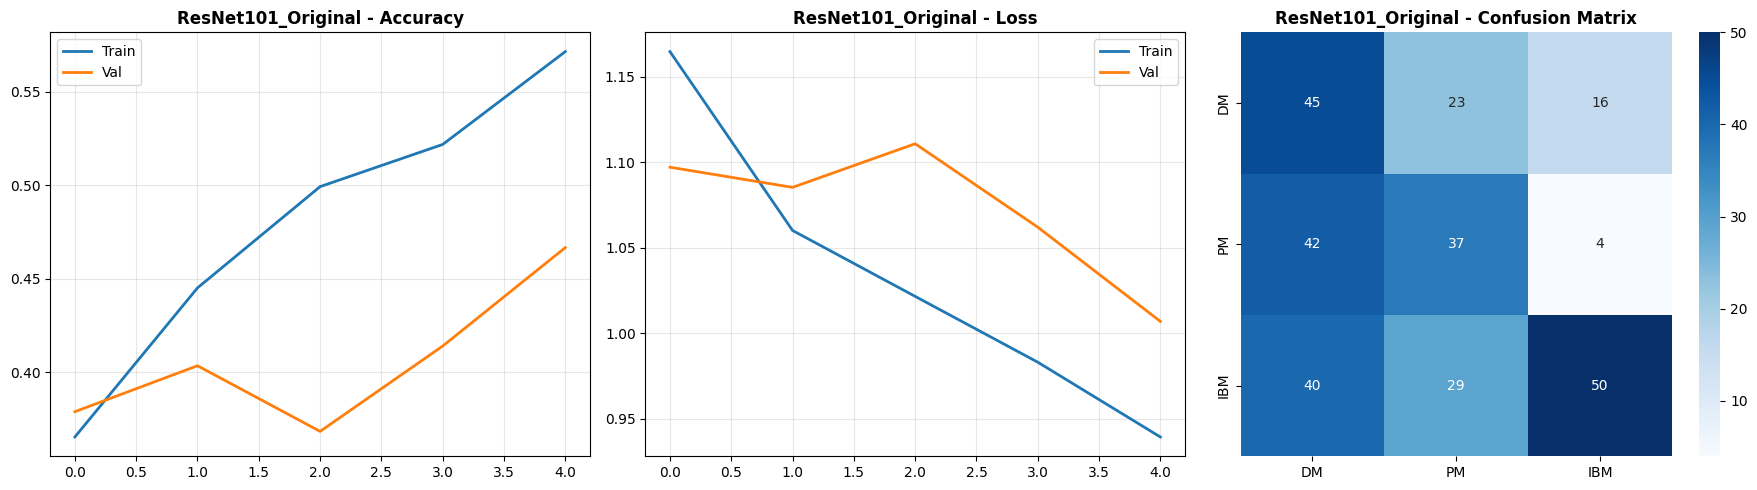


📊 ResNet101_Original: Test Acc=0.4615, F1=0.4620, Best Val=0.4667


In [11]:
# Quick test with 5 epochs on the original ResNet101 config
quick = train_single_model("ResNet101_Original", epochs=5)

## Option B: Train Priority Models (Most Likely to Beat 67%)


📋 To train: ['ResNet101_Original', 'EfficientNetB4', 'InceptionV3', 'Xception']

🚀 TRAINING: ResNet101_Original (LR=1e-05)
   ResNet101_Original: Trainable=56/346
Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.3270 - loss: 1.3168
Epoch 1: val_accuracy improved from -inf to 0.42456, saving model to /content/drive/MyDrive/MSK project/results_v2/ResNet101_Original_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 55s 657ms/step - accuracy: 0.3271 - loss: 1.3144 - val_accuracy: 0.4246 - val_loss: 1.0845 - learning_rate: 1.0000e-05
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.3810 - loss: 1.0925
Epoch 2: val_accuracy improved from 0.42456 to 0.49123, saving model to /content/drive/MyDrive/MSK project/results_v2/ResNet101_Original_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 43s 717ms/step - accuracy: 0.3813 - loss: 1.0923 - val_accuracy: 0.4912 - val_loss: 1.0578 - learning_rate: 1.0000e-05
Epoch 3/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.4422 - loss: 

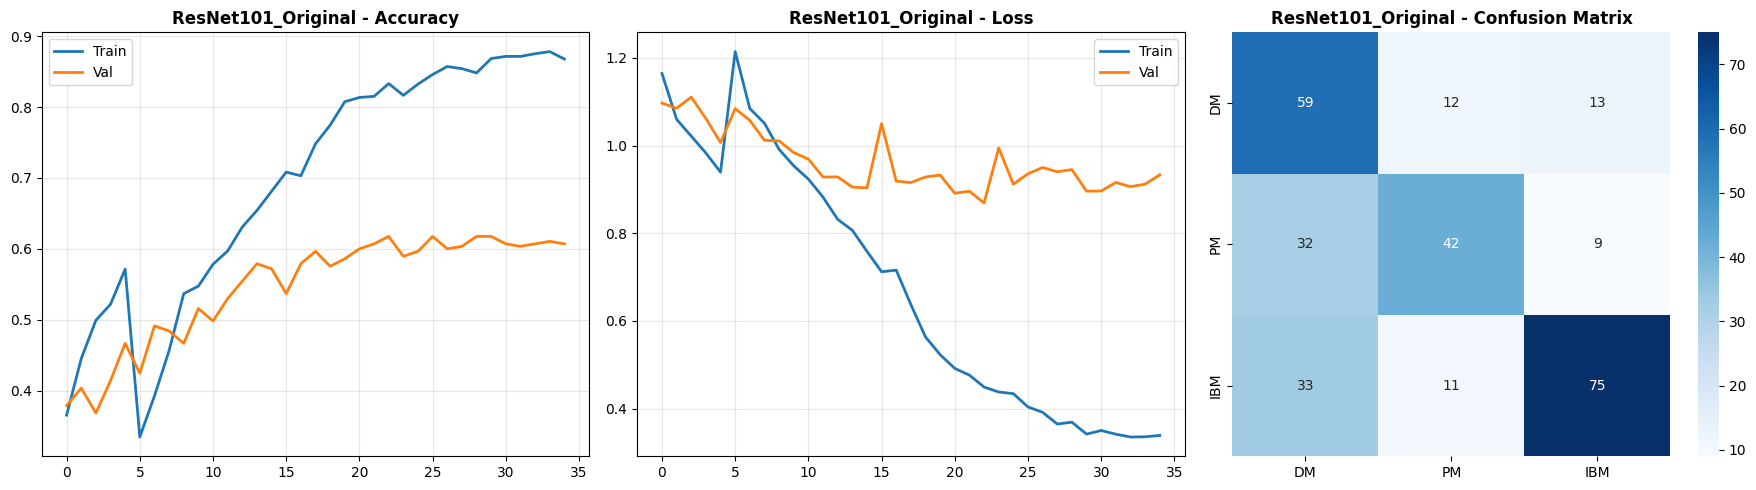


📊 ResNet101_Original: Test Acc=0.6154, F1=0.6098, Best Val=0.6175
💾 Progress saved! Completed: ['ResNet101_Original']

🚀 TRAINING: EfficientNetB4 (LR=1e-05)
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   EfficientNetB4: Trainable=80/476
Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.3119 - loss: 1.1448
Epoch 1: val_accuracy improved from -inf to 0.35439, saving model to /content/drive/MyDrive/MSK project/results_v2/EfficientNetB4_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 58s 599ms/step - accuracy: 0.3130 - loss: 1.1441 - val_accuracy: 0.3544 - val_loss: 1.0970 - learning_rate: 1.0000e-05
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.4319 - loss: 1.0723
Epoch 2: val_accuracy improved from 0.35439 to 0.43860, saving model to /content/drive/MyDrive/MSK project/results_v2/EfficientNetB4_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 433ms/step - accuracy: 0.4317 - loss: 1.0725 - val_accuracy: 0.4386 - val_loss: 1.0614 - learning_rate: 1.0000e-05
Epoch 

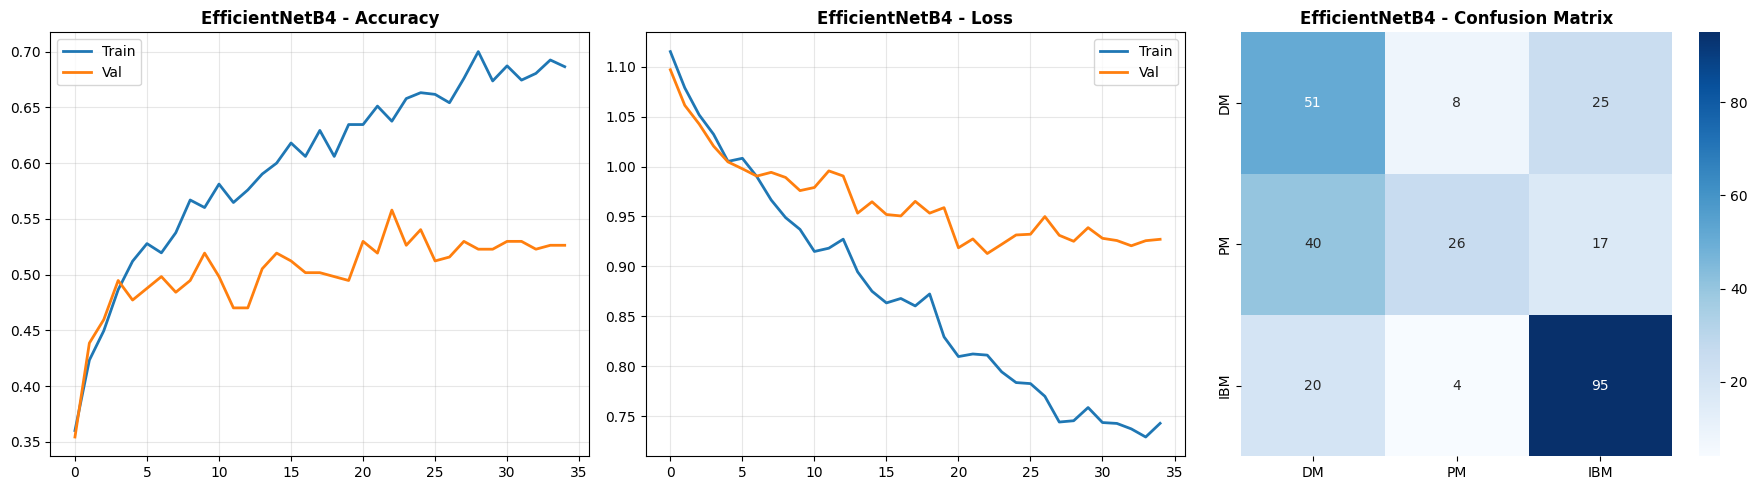


📊 EfficientNetB4: Test Acc=0.6014, F1=0.5650, Best Val=0.5579
💾 Progress saved! Completed: ['ResNet101_Original', 'EfficientNetB4']

🚀 TRAINING: InceptionV3 (LR=1e-05)
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   InceptionV3: Trainable=70/312
Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.3528 - loss: 1.2314
Epoch 1: val_accuracy improved from -inf to 0.40702, saving model to /content/drive/MyDrive/MSK project/results_v2/InceptionV3_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 460ms/step - accuracy: 0.3536 - loss: 1.2296 - val_accuracy: 0.4070 - val_loss: 1.0817 - learning_rate: 1.0000e-05
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.4200 - loss: 1.0785
Epoch 2: val_accuracy improved from 0.40702 to 0.51930, saving model to /content/drive/MyDrive/MSK project/results_v2/InceptionV3_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 383ms/step - accuracy: 0.4205 - loss: 1.0780 - val_accuracy: 0.5193 - val_loss: 1.0348 - learning_rate: 1.0000e-05
Epoc

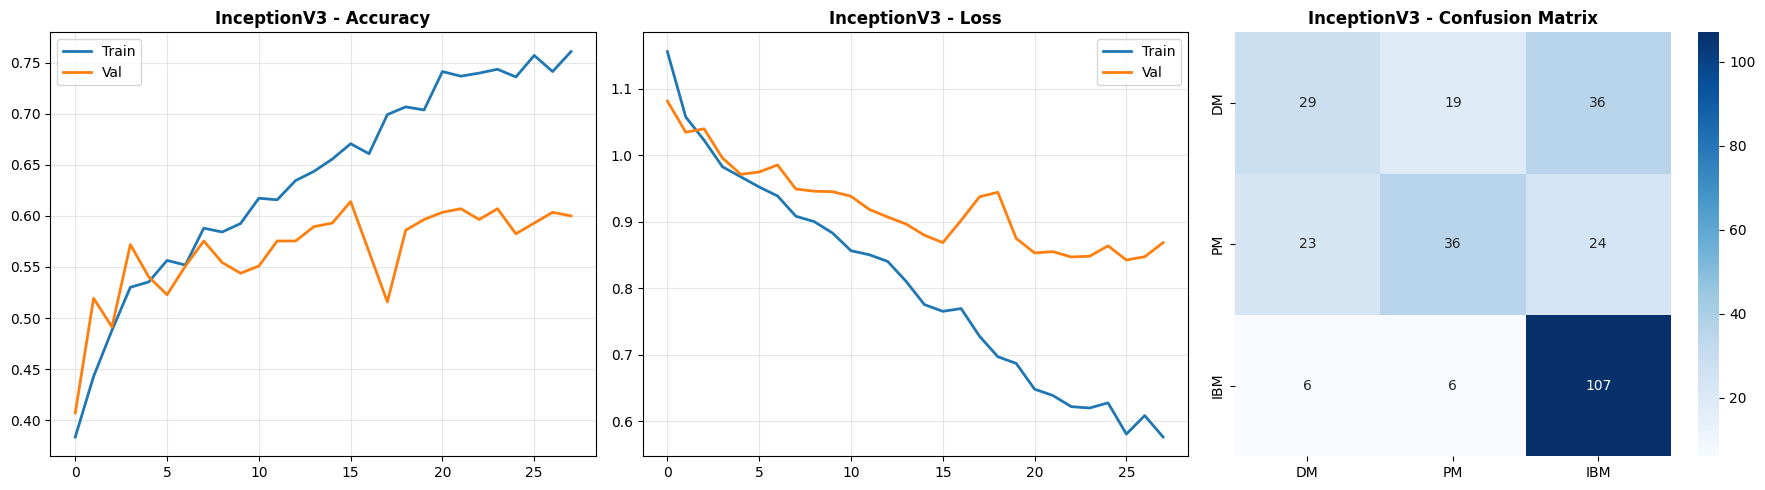


📊 InceptionV3: Test Acc=0.6014, F1=0.5522, Best Val=0.6140
💾 Progress saved! Completed: ['ResNet101_Original', 'EfficientNetB4', 'InceptionV3']

🚀 TRAINING: Xception (LR=1e-05)
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Xception: Trainable=56/133
Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.3370 - loss: 1.1117
Epoch 1: val_accuracy improved from -inf to 0.42456, saving model to /content/drive/MyDrive/MSK project/results_v2/Xception_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 44s 568ms/step - accuracy: 0.3373 - loss: 1.1115 - val_accuracy: 0.4246 - val_loss: 1.0623 - learning_rate: 1.0000e-05
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4308 - loss: 1.0743
Epoch 2: val_accuracy improved from 0.42456 to 0.45614, saving model to /content/drive/MyDrive/MSK project/results_v2/Xception_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 27s 465ms/step - accuracy: 0.4309 - loss: 1.0741 - val_accuracy: 0.4561 - val_loss: 1.0349 - learning_rate: 1.0000e-05
Epoc

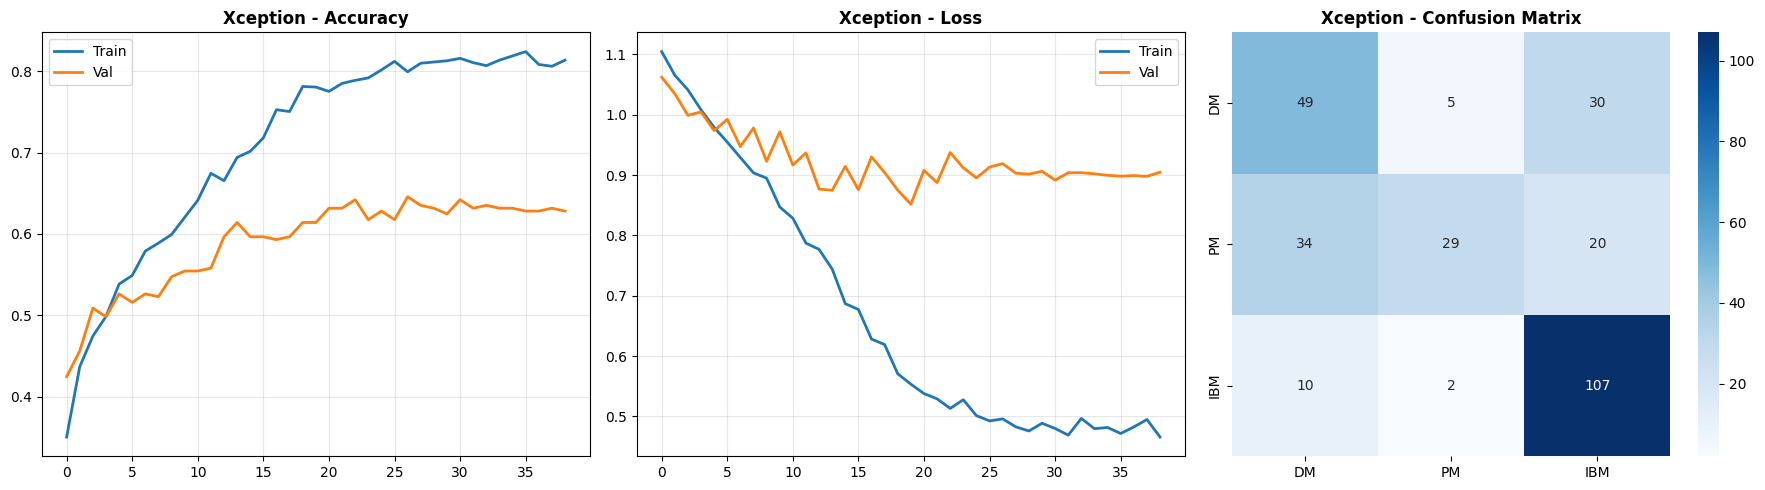


📊 Xception: Test Acc=0.6469, F1=0.6055, Best Val=0.6456
💾 Progress saved! Completed: ['ResNet101_Original', 'EfficientNetB4', 'InceptionV3', 'Xception']

📊 RESULTS
             model  test_accuracy  f1_macro  best_val_acc  epochs
          Xception       0.646853  0.605477      0.645614      39
ResNet101_Original       0.615385  0.609773      0.617544      35
    EfficientNetB4       0.601399  0.565005      0.557895      35
       InceptionV3       0.601399  0.552234      0.614035      28

🏆 Best: Xception (0.6469)


In [12]:
# Priority models - these have the best chance of beating 67%
PRIORITY_MODELS = ["ResNet101_Original", "EfficientNetB4", "InceptionV3", "Xception"]

completed, all_results = load_progress()
remaining = [m for m in PRIORITY_MODELS if m not in completed]

print(f"\n📋 To train: {remaining}")

for name in remaining:
    try:
        result = train_single_model(name, epochs=40)
        all_results.append(result)
        completed.append(name)
        save_progress(completed, all_results)
    except Exception as e:
        print(f"❌ Error: {e}")
        save_progress(completed, all_results)
        raise

# Results
if all_results:
    df_results = pd.DataFrame(all_results).sort_values("test_accuracy", ascending=False)
    print("\n" + "="*60)
    print("📊 RESULTS")
    print("="*60)
    print(df_results.to_string(index=False))
    df_results.to_csv(os.path.join(RESULTS_DIR, "comparison.csv"), index=False)
    print(f"\n🏆 Best: {df_results.iloc[0]['model']} ({df_results.iloc[0]['test_accuracy']:.4f})")

## Option C: Train All Models

📂 Found progress: ['ResNet101_Original', 'EfficientNetB4', 'InceptionV3', 'Xception']
📋 To train: ['ResNet50_Original', 'EfficientNetB0_Simple', 'DenseNet121_Simple']

🚀 TRAINING: ResNet50_Original (LR=1e-05)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   ResNet50_Original: Trainable=35/176
Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.3414 - loss: 1.2711
Epoch 1: val_accuracy improved from -inf to 0.42807, saving model to /content/drive/MyDrive/MSK project/results_v2/ResNet50_Original_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 490ms/step - accuracy: 0.3422 - loss: 1.2693 - val_accuracy: 0.4281 - val_loss: 1.0708 - learning_rate: 1.0000e-05
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.4231 - loss: 1.0827
Epoch 2: val_accuracy improved from 0.42807 to 0.49825, saving model to /content/drive/MyDrive/MSK project/results_v2/ResNet50_Original_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 421ms/step - accuracy: 0.4239 - loss: 1.0820 - val_accuracy: 

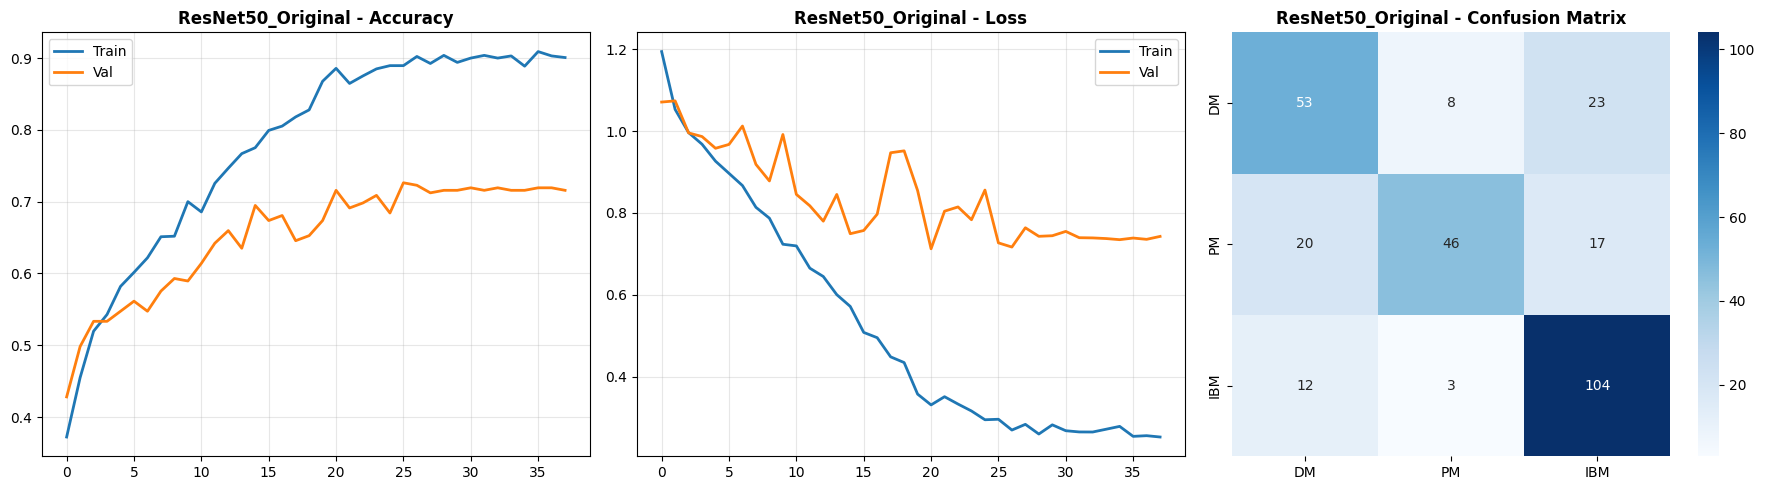


📊 ResNet50_Original: Test Acc=0.7098, F1=0.6917, Best Val=0.7263
💾 Progress saved! Completed: ['ResNet101_Original', 'EfficientNetB4', 'InceptionV3', 'Xception', 'ResNet50_Original']

🚀 TRAINING: EfficientNetB0_Simple (LR=1e-05)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   EfficientNetB0_Simple: Trainable=63/239
Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.3108 - loss: 1.1417
Epoch 1: val_accuracy improved from -inf to 0.45263, saving model to /content/drive/MyDrive/MSK project/results_v2/EfficientNetB0_Simple_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 36s 353ms/step - accuracy: 0.3109 - loss: 1.1414 - val_accuracy: 0.4526 - val_loss: 1.0812 - learning_rate: 1.0000e-05
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.4291 - loss: 1.0954
Epoch 2: val_accuracy did not improve from 0.45263
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 257ms/step - accuracy: 0.4292 - loss: 1.0953 - val_accuracy: 0.3930 - val_loss: 1.0872 - learning_rate: 1.0000e-05
Epoch 3/40
42

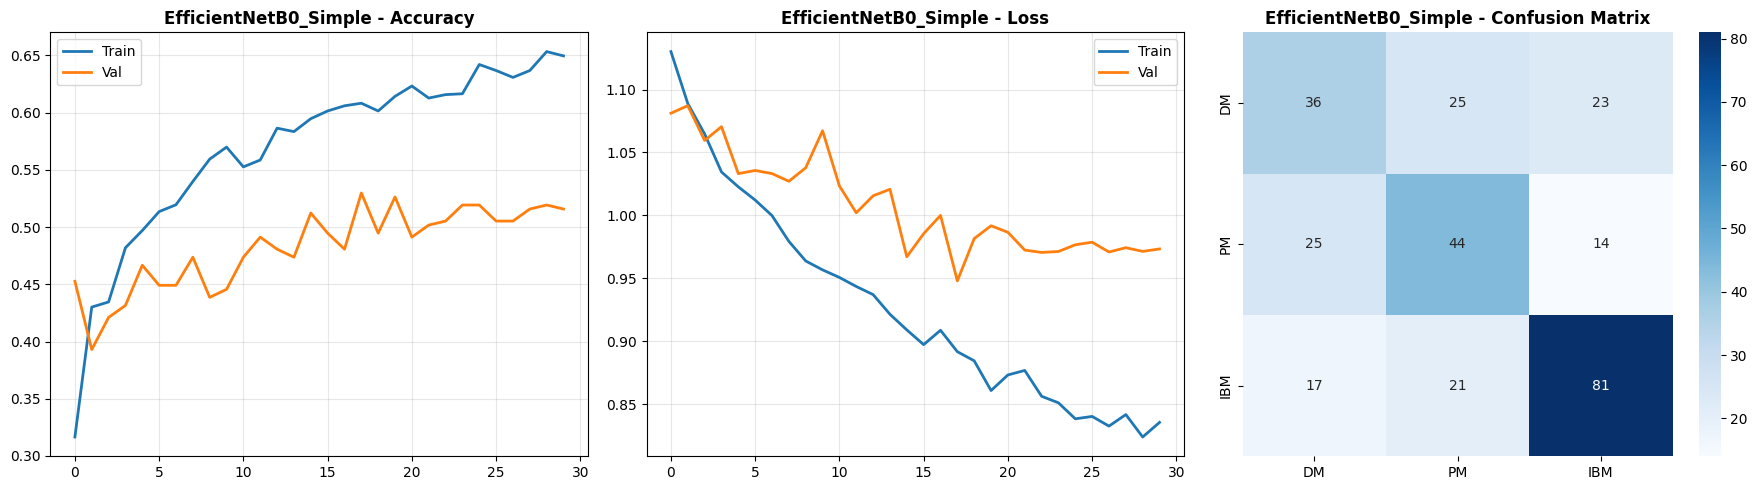


📊 EfficientNetB0_Simple: Test Acc=0.5629, F1=0.5456, Best Val=0.5298
💾 Progress saved! Completed: ['ResNet101_Original', 'EfficientNetB4', 'InceptionV3', 'Xception', 'ResNet50_Original', 'EfficientNetB0_Simple']

🚀 TRAINING: DenseNet121_Simple (LR=1e-05)
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   DenseNet121_Simple: Trainable=57/428
Epoch 1/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3720 - loss: 1.2977
Epoch 1: val_accuracy improved from -inf to 0.29123, saving model to /content/drive/MyDrive/MSK project/results_v2/DenseNet121_Simple_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 541ms/step - accuracy: 0.3717 - loss: 1.2969 - val_accuracy: 0.2912 - val_loss: 1.2209 - learning_rate: 1.0000e-05
Epoch 2/40
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.3591 - loss: 1.2175
Epoch 2: val_accuracy improved from 0.29123 to 0.30877, saving model to /content/drive/MyDrive/MSK project/results_v2/DenseNet121_Simple_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 359ms/step 

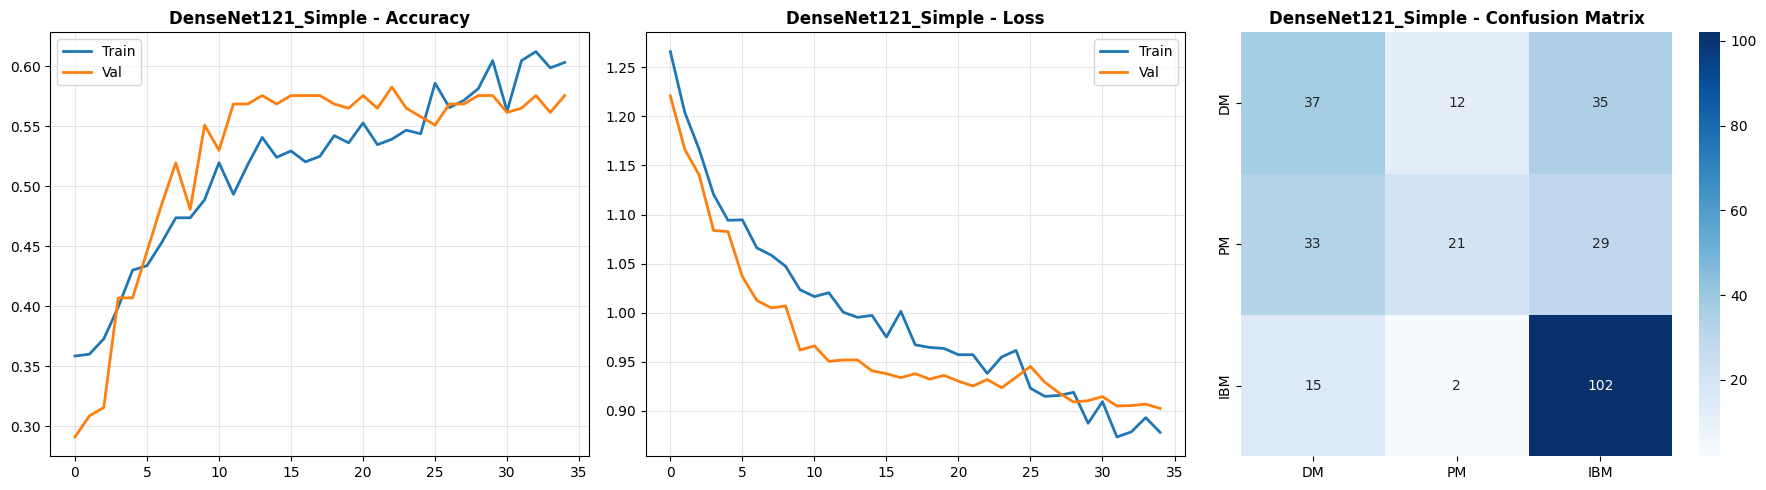


📊 DenseNet121_Simple: Test Acc=0.5594, F1=0.5032, Best Val=0.5825
💾 Progress saved! Completed: ['ResNet101_Original', 'EfficientNetB4', 'InceptionV3', 'Xception', 'ResNet50_Original', 'EfficientNetB0_Simple', 'DenseNet121_Simple']

📊 FINAL COMPARISON
                model  test_accuracy  f1_macro  best_val_acc  epochs
    ResNet50_Original       0.709790  0.691745      0.726316      38
             Xception       0.646853  0.605477      0.645614      39
   ResNet101_Original       0.615385  0.609773      0.617544      35
          InceptionV3       0.601399  0.552234      0.614035      28
       EfficientNetB4       0.601399  0.565005      0.557895      35
EfficientNetB0_Simple       0.562937  0.545553      0.529825      30
   DenseNet121_Simple       0.559441  0.503197      0.582456      35


In [13]:
ALL_MODELS = list(MODEL_CONFIGS.keys())
completed, all_results = load_progress()
remaining = [m for m in ALL_MODELS if m not in completed]

print(f"📋 To train: {remaining}")

for name in remaining:
    try:
        result = train_single_model(name, epochs=40)
        all_results.append(result)
        completed.append(name)
        save_progress(completed, all_results)
    except Exception as e:
        print(f"❌ Error: {e}")
        save_progress(completed, all_results)
        raise

df_results = pd.DataFrame(all_results).sort_values("test_accuracy", ascending=False)
print("\n📊 FINAL COMPARISON")
print(df_results.to_string(index=False))
df_results.to_csv(os.path.join(RESULTS_DIR, "comparison.csv"), index=False)

## Clear Progress (Start Fresh)

In [14]:
# Uncomment to start fresh
# clear_progress()

---
## Generate Comparison Table Image

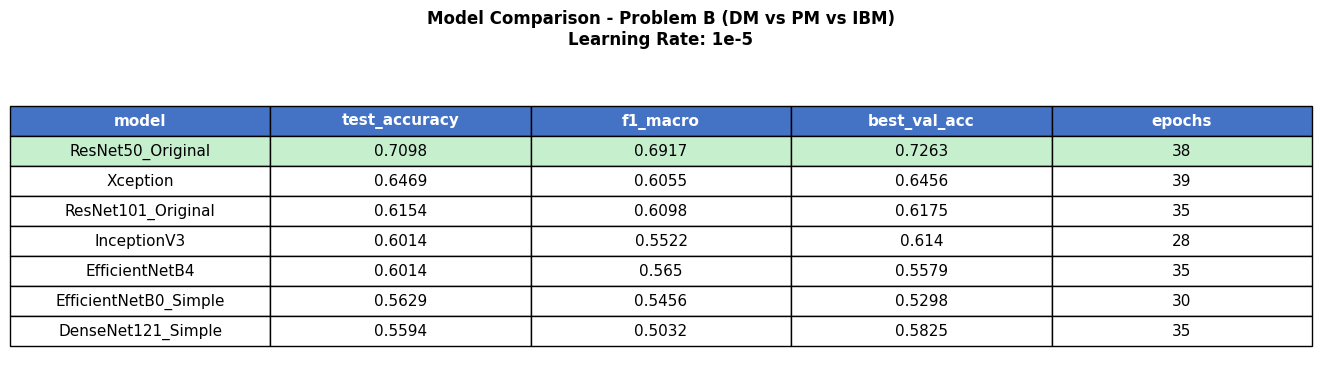

✅ Saved to /content/drive/MyDrive/MSK project/results_v2/comparison_table.png


In [15]:
comp_file = os.path.join(RESULTS_DIR, "comparison.csv")
if os.path.exists(comp_file):
    df = pd.read_csv(comp_file).round(4)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.axis('off')

    table = ax.table(cellText=df.values, colLabels=df.columns,
                     cellLoc='center', loc='center',
                     colColours=['#4472C4']*len(df.columns))
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)

    for i in range(len(df.columns)):
        table[(0, i)].set_text_props(color='white', fontweight='bold')
        table[(1, i)].set_facecolor('#C6EFCE')  # Highlight best

    plt.title("Model Comparison - Problem B (DM vs PM vs IBM)\nLearning Rate: 1e-5", fontweight='bold', pad=20)
    plt.savefig(os.path.join(RESULTS_DIR, "comparison_table.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved to {RESULTS_DIR}/comparison_table.png")
else:
    print("⚠️ No results yet - train models first!")